# Phase 4: Sparse Autoencoder Features, and Steering With Them

Phase 3 ended with a precise but unsatisfying answer: the France-vs-Italy information lives in the residual stream at the country token until layer 8, then three attention heads carry it to the answer position. But "the residual stream at the country token" is a 768-dimensional vector in superposition with everything else the model tracks. We know *where* the information is, not *what it looks like*.

**Sparse autoencoders (SAEs)** are the current tool for that. An SAE is trained to rewrite a residual-stream vector as a sparse sum of a large dictionary of directions ("features"), such that each feature tends to mean one thing. This notebook uses [Joseph Bloom's pretrained GPT-2 Small residual-stream SAEs](https://huggingface.co/jbloom/GPT2-Small-SAEs-Reformatted) (24,576 features per layer) via SAELens, and asks:

1. Do the SAEs reconstruct well enough to trust on *this* behavior?
2. What features are active at the country token, and is "France" one feature or many?
3. Does the SAE see the layer 9–10 hand-off that patching found?
4. Can we **steer** the model from Rome to Paris by editing features, and does *where* we edit matter?

The theory (why superposition forces this, how SAEs are trained) is on the [Superposition & Features](../superposition-features.html) curriculum page; here we use them.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(""))          # experiments/ on the path
sys.path.insert(0, os.path.abspath("experiments"))  # when run from repo root
import warnings; warnings.filterwarnings("ignore")
import logging; logging.getLogger().setLevel(logging.ERROR)
import torch, numpy as np, pandas as pd
import plotly.express as px, plotly.graph_objects as go, plotly.io as pio
from plotly.subplots import make_subplots
pio.renderers.default = "png"          # static images: render on GitHub, no JS needed
pio.templates.default = "plotly_white"
from interp_utils import *
print(f"device={DEVICE}")

device=mps


In [2]:
from sae_lens import SAE
import json, urllib.request

model = load_gpt2()
paris, rome = answer_ids(model)
clean_tokens, corrupt_tokens = model.to_tokens(CLEAN_PROMPT), model.to_tokens(CORRUPT_PROMPT)
str_toks = model.to_str_tokens(clean_tokens[0])
COUNTRY = str_toks.index(" France")
clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupt_logits, corrupt_cache = model.run_with_cache(corrupt_tokens)
CLEAN_LD, CORRUPT_LD = logit_diff(clean_logits, paris, rome).item(), logit_diff(corrupt_logits, paris, rome).item()
print(f"clean logit diff {CLEAN_LD:+.2f}, corrupted {CORRUPT_LD:+.2f}")

LAYERS = [6, 8, 9, 10]
saes = {}
for L in LAYERS:
    s = SAE.from_pretrained(release="gpt2-small-res-jb", sae_id=f"blocks.{L}.hook_resid_pre", device=DEVICE)
    saes[L] = s[0] if isinstance(s, tuple) else s
hook = lambda L: f"blocks.{L}.hook_resid_pre"
print({L: (saes[L].cfg.d_sae, saes[L].cfg.metadata.neuronpedia_id) for L in LAYERS})

def neuronpedia(L, fid):
    # Auto-interp explanation from Neuronpedia's public API; empty string if offline.
    try:
        url = f"https://www.neuronpedia.org/api/feature/gpt2-small/{L}-res-jb/{fid}"
        d = json.load(urllib.request.urlopen(urllib.request.Request(url, headers={"User-Agent": "interp-notebook"}), timeout=15))
        return (d.get("explanations") or [{}])[0].get("description", "")
    except Exception:
        return ""

def decoder_readout(L, fid, k=6):
    # Which tokens does this feature's decoder direction promote if it reached the unembedding directly?
    sc = (saes[L].W_dec[fid] / clean_cache["ln_final.hook_scale"][0, -1]) @ model.W_U
    return [model.to_string(i.item()) for i in sc.topk(k).indices]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
clean logit diff +6.05, corrupted -6.42


{6: (24576, 'gpt2-small/6-res-jb'), 8: (24576, 'gpt2-small/8-res-jb'), 9: (24576, 'gpt2-small/9-res-jb'), 10: (24576, 'gpt2-small/10-res-jb')}


## 1. Can we trust these SAEs here?

An SAE is an approximation. Before reading features off it, check two things: how much of the residual stream it reconstructs, and, more importantly, whether the model still *behaves the same* when the SAE's reconstruction is spliced in place of the real activation.

In [3]:
rows = []
for L in LAYERS:
    sae = saes[L]; a = clean_cache[hook(L)]
    feats = sae.encode(a)
    rel_err = ((sae.decode(feats) - a).norm() / a.norm()).item()
    def splice(act, hook): return sae.decode(sae.encode(act))
    spliced = logit_diff(model.run_with_hooks(clean_tokens, fwd_hooks=[(hook(L), splice)]), paris, rome).item()
    rows.append(dict(layer=L, rel_recon_error=round(rel_err, 3), active_feats_country=int((feats[0, COUNTRY] > 0).sum()),
                     active_feats_final=int((feats[0, -1] > 0).sum()), logit_diff_spliced=round(spliced, 2), logit_diff_true=round(CLEAN_LD, 2)))
pd.DataFrame(rows)

,layer,rel_recon_error,active_feats_country,active_feats_final,logit_diff_spliced,logit_diff_true
0,6,0.022,38,70,4.15,6.05
1,8,0.030,62,104,6.14,6.05
2,9,0.036,60,99,5.21,6.05
3,10,0.054,63,61,6.30,6.05


Reconstruction error is 2–5% by norm, and the SAEs use 40–100 of their 24,576 features per token. The behavioral check is the one that matters: splicing the **layer 8** or **layer 10** SAE in changes the logit difference by less than 5%, while **layer 6** loses a third of it and **layer 9** loses 14%. So the layer 8 SAE is the one to lean on for the country token (it is also the last layer before the hand-off starts), and any layer 9 result deserves a grain of salt.

## 2. What is at the country token?

In [4]:
rows = []
for L in LAYERS:
    f_clean = saes[L].encode(clean_cache[hook(L)])[0, COUNTRY]
    f_corr  = saes[L].encode(corrupt_cache[hook(L)])[0, COUNTRY]
    for name, f in [("France", f_clean), ("Italy", f_corr)]:
        top = f.topk(3)
        rows.append(dict(layer=L, prompt=name, top_feature=top.indices[0].item(), act=round(top.values[0].item(), 1),
                         second=top.indices[1].item(), act2=round(top.values[1].item(), 1),
                         third=top.indices[2].item(), act3=round(top.values[2].item(), 1)))
pd.DataFrame(rows)

,layer,prompt,top_feature,act,second,act2,third,act3
0,6,France,8777,42.1,9201,8.3,3653,7.5
1,6,Italy,17587,34.7,9201,8.9,3653,8.3
2,8,France,19692,37.3,3284,10.7,13529,7.6
3,8,Italy,1437,37.4,3284,12.2,13529,7.1
4,9,France,17889,40.6,16729,13.6,21333,10.7
5,9,Italy,1188,40.7,16729,14.2,21333,11.6
6,10,France,10972,42.1,14374,15.0,7111,10.4
7,10,Italy,19544,43.0,14374,16.6,1276,11.6


At every layer, one feature fires at ~40 and everything else is at ~10 or below. The dominant feature is *different* for France and Italy, while the runners-up (e.g. feature 3284 at layer 8) are *shared*. So the SAE's view of the country token is: one big "which country" feature plus a handful of shared context features ("a country name", "inside a 'capital of' template", and so on). Let's see what the big ones mean.

In [5]:
FR = {6: 8777, 8: 19692, 9: 17889, 10: 10972}   # dominant feature at the France token per layer (from the table above)
IT = {6: 17587, 8: 1437, 9: 1188, 10: 19544}    # same, Italy
for L in [8, 10]:
    for name, fid in [("France", FR[L]), ("Italy", IT[L])]:
        print(f"L{L} #{fid:5d} {name}: decoder promotes {decoder_readout(L, fid)}")
        print(f"            Neuronpedia: {neuronpedia(L, fid) or '(offline)'}   https://www.neuronpedia.org/gpt2-small/{L}-res-jb/{fid}")

L8 #19692 France: decoder promotes [' fries', ' Hollande', ' Alps', 'bourg', 'men', ' Riv']


            Neuronpedia: mentions of the country "France."   https://www.neuronpedia.org/gpt2-small/8-res-jb/19692
L8 # 1437 Italy: decoder promotes ['igne', ' Serie', ' Fasc', 'otti', ' Alps', ' Renaissance']


            Neuronpedia: Italian-related terms and references   https://www.neuronpedia.org/gpt2-small/8-res-jb/1437
L10 #10972 France: decoder promotes [' fries', ' Hollande', 'bourg', ' franc', 'ois', ' Alps']


            Neuronpedia: mentions of the country "France."   https://www.neuronpedia.org/gpt2-small/10-res-jb/10972
L10 #19544 Italy: decoder promotes [' Serie', 'igne', ' Renaissance', 'olini', 'Italy', ' Italy']


            Neuronpedia: mentions of countries, specifically focusing on Italy   https://www.neuronpedia.org/gpt2-small/10-res-jb/19544


The decoder directions are unmistakable: the France feature promotes " Hollande", " Alps", " fries", "bourg", " franc", " Macron"; the Italy feature promotes "igne", " Serie", "otti", " Renaissance". Neuronpedia's automatic explanations (generated from where these features fire across a large corpus) agree.

Notice what the France feature is *not*: a Paris feature. Its top readouts are French culture, politics, geography. That is the same finding as Phase 2, now at the feature level: the country token carries "France, broadly", and the *circuit* (L9H8's OV matrix, and what the answer position is expecting) turns it into "Paris".

### Is it the same feature across layers?

The residual stream is persistent, so a feature written early should still be readable later. The SAEs are trained independently per layer, so there is no guarantee they pick the same direction. Check the cosine similarity between the France decoder directions.

In [6]:
import itertools
rows = []
for a, b in itertools.combinations(LAYERS, 2):
    rows.append(dict(pair=f"L{a} vs L{b}", cos_France=round(torch.cosine_similarity(saes[a].W_dec[FR[a]], saes[b].W_dec[FR[b]], dim=0).item(), 2)))
within = {L: round(torch.cosine_similarity(saes[L].W_dec[FR[L]], saes[L].W_dec[IT[L]], dim=0).item(), 2) for L in LAYERS}
print(pd.DataFrame(rows).to_string(index=False))
print("\ncos(France, Italy) within the same layer:", within)

     pair  cos_France
 L6 vs L8        0.92
 L6 vs L9        0.88
L6 vs L10        0.86
 L8 vs L9        0.96
L8 vs L10        0.93
L9 vs L10        0.97

cos(France, Italy) within the same layer: {6: 0.4, 8: 0.32, 9: 0.28, 10: 0.25}


Cosine similarity of 0.86–0.97 between France features at different layers, versus 0.28–0.40 between France and Italy at the same layer. Four independently trained dictionaries found essentially the same "France" direction, and it persists in the residual stream from layer 6 to layer 10 with little rotation. (The France/Italy similarity of ~0.3 is the shared "European country" component.)

### One feature per country

If this is how the model represents countries, every country should get its own dominant feature.

In [7]:
rows = []
for c in ["France", "Italy", "Germany", "Japan", "Spain", "Egypt", "Russia", "Canada"]:
    p = f"The capital of Germany is Berlin. The capital of {c} is" if c != "Germany" else "The capital of France is Paris. The capital of Germany is"
    toks = model.to_tokens(p); _, ch = model.run_with_cache(toks); pos = model.to_str_tokens(toks[0]).index(f" {c}")
    f = saes[8].encode(ch[hook(8)])[0, pos]; top = f.topk(2)
    rows.append(dict(country=c, L8_feature=top.indices[0].item(), act=round(top.values[0].item(), 1), runner_up=top.indices[1].item(),
                     act2=round(top.values[1].item(), 1), decoder_promotes=decoder_readout(8, top.indices[0].item(), 5)))
pd.DataFrame(rows)

,country,L8_feature,act,runner_up,act2,decoder_promotes
0,France,19692,37.3,3284,10.7,"[ fries, Hollande, Alps, bourg, men]"
1,Italy,1437,37.4,3284,12.2,"[igne, Serie, Fasc, otti, Alps]"
2,Germany,23151,30.9,20901,14.0,"[ Chancellor, geist, wings, Munich, Bundesliga]"
3,Japan,9482,36.7,3284,9.3,"[ Yen, yen, imura, oka, iji]"
4,Spain,3037,37.8,3284,11.8,"[ Inquisition, Nieto, Libre, pes, Rican]"
5,Egypt,22482,46.2,3284,9.4,"[osph, Egyptians, hier, ologists, Air]"
6,Russia,4735,45.6,3284,9.4,"[ annexed, Federation, kaya, Today, �]"
7,Canada,1567,40.6,3284,9.4,"[ Goose, Tire, Centre, Scotia, Institutes]"


Eight countries, eight different dominant features, each with a recognizable readout (Germany → " Chancellor", " Munich", " Bundesliga"; Japan → " Yen", "imura"; Canada → " Goose", " Scotia"), and the same runner-up feature 3284 for nearly all of them. This is what a clean, interpretable representation looks like, and it is worth remembering how unusual that is: most tokens in most contexts are not this tidy.

## 3. Does the SAE see the hand-off?

Phase 3 showed the country identity moving from the country token to the answer token across layers 9–10. If that is real, France-specific features should start firing *at the answer position* at exactly those layers.

In [8]:
rows = []
for L in LAYERS:
    f_clean = saes[L].encode(clean_cache[hook(L)])[0, -1]
    f_corr  = saes[L].encode(corrupt_cache[hook(L)])[0, -1]
    diff = f_clean - f_corr; top = diff.topk(1)
    fid = top.indices[0].item()
    rows.append(dict(layer=L, largest_France_only_feature=fid, activation=round(top.values[0].item(), 1),
                     total_L1_difference=round(diff.abs().sum().item(), 1), decoder_promotes=decoder_readout(L, fid, 5)))
df = pd.DataFrame(rows); df

,layer,largest_France_only_feature,activation,total_L1_difference,decoder_promotes
0,6,6541,0.9,19.0,"[ cz, ��, Bast, Jackets, Bre]"
1,8,13033,0.6,30.6,"[ France, Georgia, Spain, Brazil, South]"
2,9,22250,11.5,152.1,"[ Ré, É, à, Franç, France]"
3,10,7790,38.1,242.8,"[ French, France, France, Hollande, Marse]"


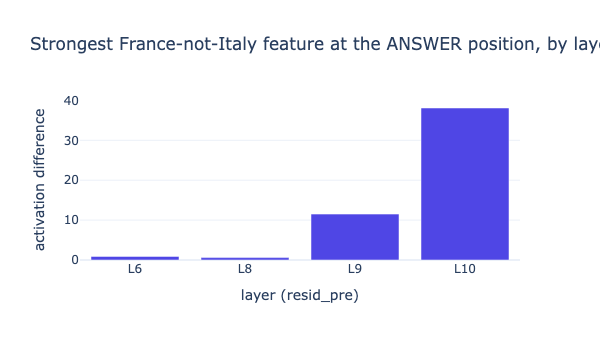

In [9]:
fig = px.bar(df, x=[f"L{l}" for l in df.layer], y="activation", title="Strongest France-not-Italy feature at the ANSWER position, by layer",
             labels=dict(x="layer (resid_pre)", activation="activation difference"), color_discrete_sequence=["#4f46e5"])
fig.update_layout(width=600, height=340); fig.show()

Nothing at layers 6 and 8 (the strongest France-specific feature at the answer position is below 1), a clear signal at layer 9 (feature 22250, readout " Franç", " François", " France", activation 11.5), and a dominant one at layer 10 (feature 7790, readout " French", " France", " Paris", activation 38). That is the hand-off, seen from the feature side: L8H11 writes a little at layer 8 (visible at layer 9's input), L9H8 writes most of it at layer 9 (visible at layer 10's input). Two completely different methods, one built on intervention and one on a learned dictionary, agree on the layer, the position and the direction.

## 4. Steering: rewrite the fact

If the country token's identity is one feature, we should be able to change the model's answer by swapping that feature: on the *Italy* prompt, subtract the Italy feature and add the France feature, scaled to the activations they normally have. This is a **feature swap**, the SAE version of a steering vector.

In [10]:
def feature_swap(L, coef=1.0, pos=COUNTRY, remove=None, add=None):
    sae = saes[L]
    f_clean = sae.encode(clean_cache[hook(L)])[0, pos]; f_corr = sae.encode(corrupt_cache[hook(L)])[0, pos]
    remove = IT[L] if remove is None else remove; add = FR[L] if add is None else add
    delta = coef * (f_clean[add] * sae.W_dec[add] - f_corr[remove] * sae.W_dec[remove])
    def hook_fn(act, hook):
        act[:, pos] += delta; return act
    out = model.run_with_hooks(corrupt_tokens, fwd_hooks=[(hook(L), hook_fn)])
    pr = out[0, -1].softmax(-1)
    return dict(logit_diff=round(logit_diff(out, paris, rome).item(), 2), P_paris=round(pr[paris].item(), 3), P_rome=round(pr[rome].item(), 3),
                top3=[model.to_string(i.item()) for i in pr.topk(3).indices])

print("layer 8, country token, Italy→France feature swap at increasing strength:")
for coef in [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]:
    print(f"  ×{coef:<4} {feature_swap(8, coef)}")

layer 8, country token, Italy→France feature swap at increasing strength:
  ×0.0  {'logit_diff': -6.42, 'P_paris': 0.001, 'P_rome': 0.617, 'top3': [' Rome', ' Milan', ' Florence']}
  ×0.5  {'logit_diff': -1.58, 'P_paris': 0.065, 'P_rome': 0.318, 'top3': [' Rome', ' Milan', ' Florence']}
  ×1.0  {'logit_diff': 5.68, 'P_paris': 0.629, 'P_rome': 0.002, 'top3': [' Paris', ' Lyon', ' Marse']}
  ×1.5  {'logit_diff': 7.66, 'P_paris': 0.521, 'P_rome': 0.0, 'top3': [' Paris', ' Lyon', ' Marse']}
  ×2.0  {'logit_diff': 7.31, 'P_paris': 0.339, 'P_rome': 0.0, 'top3': [' Paris', ' Lyon', ' Marse']}
  ×3.0  {'logit_diff': 6.55, 'P_paris': 0.176, 'P_rome': 0.0, 'top3': [' Paris', ' Lyon', ' the']}


At ×1.0 (replace the Italy feature with the France feature at its natural activation) the model answers **" Paris" at 63%**, close to the 70% it gives on the real France prompt, with " Lyon" and " Marseille" as runners-up, exactly as on the real prompt. At ×0.5 it is still Rome. Past ×1.5 Paris stays top but the probability *drops* as the residual stream leaves its normal range; more steering is not better steering.

Now the interesting part: **where** we apply the swap.

In [11]:
print("×1.0 feature swap at the COUNTRY token, by layer:")
for L in LAYERS:
    print(f"  L{L}: {feature_swap(L, 1.0)}")
print("\n×1.0 swap of the ANSWER-position features at layer 10 (7790 ↔ 20536):")
print(f"  L10: {feature_swap(10, 1.0, pos=-1, remove=20536, add=7790)}")

×1.0 feature swap at the COUNTRY token, by layer:
  L6: {'logit_diff': 5.54, 'P_paris': 0.55, 'P_rome': 0.002, 'top3': [' Paris', ' Lyon', ' Marse']}
  L8: {'logit_diff': 5.68, 'P_paris': 0.629, 'P_rome': 0.002, 'top3': [' Paris', ' Lyon', ' Marse']}
  L9: {'logit_diff': 1.48, 'P_paris': 0.326, 'P_rome': 0.074, 'top3': [' Paris', ' Marse', ' Rome']}
  L10: {'logit_diff': -4.25, 'P_paris': 0.008, 'P_rome': 0.542, 'top3': [' Rome', ' Milan', ' Florence']}

×1.0 swap of the ANSWER-position features at layer 10 (7790 ↔ 20536):


  L10: {'logit_diff': -0.72, 'P_paris': 0.116, 'P_rome': 0.239, 'top3': [' Rome', ' Milan', ' Paris']}


The same edit at the same token works at layers 6 and 8, **half-works at layer 9** (Paris 33%, Rome still 7%) and **fails at layer 10**. Phase 3 explains why: by layer 9's input, L8H11 has already read the country token, so only L9H8 and L10H0 see the edit; by layer 10's input, L9H8 has fired too and only L10H0 is left, which is not enough. Editing the country token after the heads that read it have fired changes nothing that reaches the output. Swapping the *answer-position* features at layer 10 instead does something (Paris 1% → 12%, Rome 62% → 24%), because that is where the information now lives, but the layer-10 attention and MLP still get to see the original.

This is the practical lesson of the whole repo so far: **steering works when it respects the circuit.** A steering vector applied at the wrong layer or position is not "weak", it is downstream of the computation it is trying to change.

In [12]:
# Ablating the France feature on the France prompt: what does the model do with no country identity?
sae = saes[8]; f = sae.encode(clean_cache[hook(8)])[0, COUNTRY]
def remove_france(act, hook):
    act[:, COUNTRY] -= f[FR[8]] * sae.W_dec[FR[8]]; return act
out = model.run_with_hooks(clean_tokens, fwd_hooks=[(hook(8), remove_france)]); pr = out[0, -1].softmax(-1)
print("France prompt with the France feature removed at layer 8:")
print(f"  logit diff {logit_diff(out, paris, rome).item():+.2f}, P(Paris)={pr[paris]:.3f}, top-5 = {[model.to_string(i.item()) for i in pr.topk(5).indices]}")

France prompt with the France feature removed at layer 8:
  logit diff +0.88, P(Paris)=0.062, top-5 = [' Berlin', ' Paris', ' Frankfurt', ' London', ' Munich']


With the France feature deleted, the model's top answer becomes **" Berlin"**: the capital that is sitting in the context. With nothing to recall, it falls back to copying. That fallback is a different circuit (induction / copy heads), and it is what the suppressor heads L10H7 and L11H10 were arguing against all along.

## 5. What we learned, and what SAEs do not give you

**Findings.**
- The country token is represented by **one dominant SAE feature per country**, plus a few shared context features. Independently trained SAEs at four layers find the same France direction (cosine 0.86–0.97).
- The France feature is a *France* feature, not a Paris feature. The circuit, not the representation, produces the capital.
- France-specific features appear at the answer position at layer 9 and dominate at layer 10, matching the patching hand-off exactly.
- A ×1.0 feature swap at layer 8 rewrites the fact (Rome → Paris at 63%). The same swap at layer 10 does nothing, because the information has already moved.

**Caveats, which are the real content of this notebook.**
- Every result above is relative to *these* dictionaries. Layer 6's SAE loses a third of the behavior when spliced in; different SAEs on the same layer find different features (see the "SAEs find different features every time" open problem). Behavior-preservation checks like Section 1 should precede any feature claim.
- "Feature 19692 means France" is an inference from decoder readouts, Neuronpedia's corpus statistics, and the swap experiment. The swap is the strong evidence; readouts alone are suggestive.
- This is a maximally clean case: a single-token proper noun in a template. Most representations will not resolve to one feature.

**Where next.** The circuit's *edges* (which feature at the country token feeds which feature at the answer token, through which head) are what attribution graphs compute automatically. That is Phase 5: cross-layer transcoders and [circuit-tracer](https://github.com/safety-research/circuit-tracer).

In [13]:
# PLAYGROUND
# - Swap France → Japan instead. Does " Tokyo" come out at ×1.0?
# - Steer with a *generic* direction: the difference of mean residual streams over 10 French vs 10 Italian sentences. Compare to the feature swap.
# - Feature 3284 fires on every country token. What is it? Check its Neuronpedia page and its readout.